# Dimensiereductie

Auteurs: Brian van der Bijl (brian.vanderbijl@hu.nl), Tijmen Muller

- Studentnummer:1881022
- Naam: Mahmut Ozcan
- Datum: 05-03-2026

## Deel I: Principal Component Analysis (PCA)

Het _Principal Component Analysis_ (PCA) algoritme kan gebruikt worden om het aantal dimensies van een dataset te reduceren tot de belangrijkste componenten. Als de originele dataset $n$ dimensies heeft, dan kunnen we met onderstaande stappen dit terugbrengen tot een (zelfgekozen) aantal van $n^\prime$ dimensies.

1. Centreer de data.
2. Bereken de covariantie van alle features onderling. 
3. Bereken de Eigenvectors en Eigenvalues van de covariantiematrix.
4. Kies de $n^\prime$ Eigenvectors om de dimensiereductie mee uit te voeren.
5. Vermenigvuldig de $n^\prime$ Eigenvectors met de originele data om de reductie toe te passen.

### Context

Gegeven is een databestand met embeddings van 200 tekstfragmenten. Elke embedding bestaat in 15 dimensies, en is gelabeled met een categorie. We gaan dimensionaliteitsreductie toepassen om de data te kunnen plotten.

De categorie geeft aan in welk genre de tekstfragmenten thuishoren. Daarnaast is onderscheid gemaakt tussen het perspectief waarin het fragment geschreven is: ik (1st person) of hij/haar/hen (3rd person):
- Fantasy (1st person)
- Fantasy (3rd person)
- Science Fiction (1st person)
- Science Fiction (3rd person)
- Romance (1st person)
- Romance (3rd person)
- Crime (1st person)
- Crime (3rd person)

In [17]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

# Show floats on 3 digits, suppress scientific notation
np.set_printoptions(precision=3, suppress=True)

In [18]:
with open('data.pkl', 'rb') as file:
    data = pickle.load(file)

data.sample(5)

e_1,e_2,e_3,e_4,e_5,e_6,e_7,e_8,e_9,e_10,e_11,e_12,e_13,e_14,e_15,label
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
1.114257,0.298521,0.505307,1.220291,0.650888,4.225836,0.305542,2.483989,1.041216,1.109795,1.069355,1.079352,0.746412,0.661405,0.919884,"""Crime (1st person)"""
1.149145,0.998675,0.957823,0.325852,0.85576,3.653724,1.615121,1.919671,0.861909,0.633758,1.048633,0.755498,1.577453,0.770792,1.413065,"""Science Fiction (3rd person)"""
1.061419,0.614988,0.927728,0.731949,0.356446,3.669673,1.440152,2.216329,0.681779,0.800794,1.177313,0.5939,1.242759,1.363502,1.068385,"""Science Fiction (3rd person)"""
1.304635,0.633523,1.092681,1.269491,1.09225,2.148762,0.13423,3.416251,1.1401,0.699332,1.183725,0.955209,0.788105,0.952567,1.230859,"""Science Fiction (1st person)"""
1.653362,1.554929,1.475294,0.677498,1.302392,3.866261,0.804821,3.102261,1.228692,0.793275,0.338367,1.633079,1.049915,1.0656,0.299805,"""Fantasy (1st person)"""


### Voorbereidende opdracht

Gegeven een dataset met $m$ datapunten met elk $n$ features en een gewenste reductie tot $n^\prime$ dimensies. Bepaal voor elk van de vijf stappen van het algoritme wat de dimensies (oftewel `shape`) is van de volgende tussenresultaten:

0. De matrix met de originele dataset.
1. De matrix met de gemiddelden per feature om de data mee te centreren.
2. De covariantiematrix.
3. De matrix met de Eigenvectors en de matrix met de Eigenvalues.
4. De matrix met de _geselecteerde_ Eigenvectors.
5. De matrix met de _gereduceerde_ data.

_Schrijf hier je antwoord._

### Opdracht 1. Implementatie

Schrijf een eigen implementatie van het PCA-algoritme `compute_pca(X, n_components)` volgens eerdergenoemde stappen van het algoritme. Maak slim gebruik van fucties van `numpy` waar mogelijk, maar zorg wel dat je begrijpt wat je in elke stap doet. De laatste stap is al gegeven in de functiedefinitie hieronder.

Hint: Laat bij stap 3. zien (bijvoorbeeld met een `print()` statement) dat de meest informatieve Eigenvalue al meer dan 50% van de informatie bevat van onze dataset.

#### Input
- `X: numpy.array` - numpy matrix met dimensies $(m, n)$; elke rij is een datapunt in $n$ dimensies
- `n_components: int` - het gewenste aantal dimensies $n^\prime$

#### Output
`X_reduced: numpy.array` - een $(m, n^\prime)$ numpy matrix met de gereduceerde data.

In [19]:
def compute_pca(X, n_components):
    """
    Parameters
    ----------
    X : numpy.ndarray
        Input data matrix of shape (m, n), where m is the number of samples and n is the number of features.
    n_components : int
        The number of principal components (dimensions) to keep.

    Returns
    -------
    X_reduced : numpy.ndarray
        The data projected onto the top n_components principal components.
    """
    arr = np.array(X)

    # Stap 1: Centreer de data
    gemiddelde = np.mean(arr, axis=0)
    arr_gecentreerd = arr - gemiddelde

    # Stap 2: Bereken de covariantiematrix
    covariantie_matrix = np.cov(arr_gecentreerd, rowvar=False)

    # Stap 3: Bereken eigenvectoren en eigenwaarden
    eigenwaarden, eigenvectoren = np.linalg.eigh(covariantie_matrix)

    percentage_variantie = eigenwaarden / np.sum(eigenwaarden) * 100
    print(f"percentage variantie per component: {percentage_variantie}")
    print(f"Grootste eigenwaarde: {percentage_variantie[-1]:.1f}%")

    # Stap 4: Selecteer de top n_components eigenvectoren
    n_eigenvectors = eigenvectoren[:, -n_components:]

    # Stap 5: Projecteer de gecentreerde data
    return np.dot(arr_gecentreerd, n_eigenvectors)

#### Test-scenario
Onderstaande code zou de volgende output moeten opleveren (het minteken kan wisselen):

```python
[[ 0.43437323 -0.49820384]
 [ 0.42077249  0.50351448]
 [-0.85514571 -0.00531064]]
 ```

In [20]:
np.random.seed(1)
X = np.random.rand(3, 10)
X_reduced = compute_pca(X, n_components=2)
print(X_reduced)

percentage variantie per component: [-0.    -0.    -0.    -0.    -0.     0.     0.     0.    31.384 68.616]
Grootste eigenwaarde: 68.6%
[[-0.498  0.434]
 [ 0.504  0.421]
 [-0.005 -0.855]]


### Opdracht 2. Visualisatie met dimensiereductie

Maak op basis van de aangeleverde `data` een numpy array van de datapunten, en gebruik je PCA-implementatie om een 2D- en 3D-weergave van de data te maken. Maak van elke weergave een plot, waarbij iedere categorie een eigen kleur krijgt.

percentage variantie per component: [ 0.861  0.879  1.009  1.085  1.253  1.301  1.458  1.665  2.03   2.743
  3.813  4.686  8.551 17.685 50.981]
Grootste eigenwaarde: 51.0%


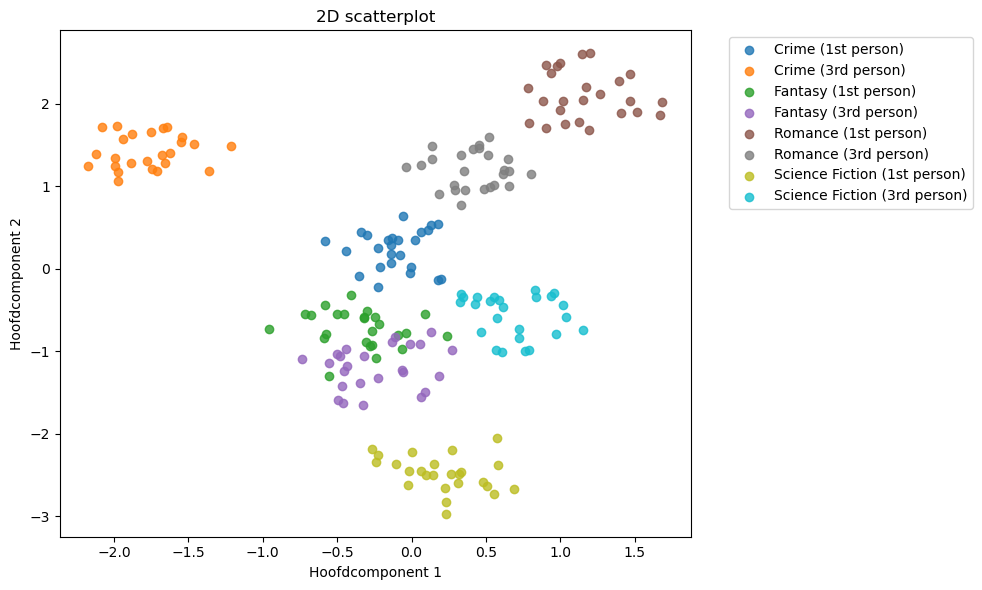

In [21]:
getal_kolommen = [kolom for kolom in data.columns if kolom != ('label')]
X = data.select(getal_kolommen).to_numpy()
labels = data['label'].to_list()
labels_lijst = np.array(labels)

unieke_labels = sorted(set(labels))
kleuren_lijst = plt.cm.tab10(np.linspace(0, 1, len(unieke_labels)))

X_pca_2d = compute_pca(X, n_components=2)

plt.figure(figsize=(10, 6))
for kleur, label in zip(kleuren_lijst, unieke_labels):
    masker = labels_lijst == label
    plt.scatter(
        X_pca_2d[masker, 0],
        X_pca_2d[masker, 1],
        label=label,
        color=kleur,
        alpha=0.8,
    )

plt.title('2D scatterplot')
plt.xlabel('Hoofdcomponent 1')
plt.ylabel('Hoofdcomponent 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

percentage variantie per component: [ 0.861  0.879  1.009  1.085  1.253  1.301  1.458  1.665  2.03   2.743
  3.813  4.686  8.551 17.685 50.981]
Grootste eigenwaarde: 51.0%


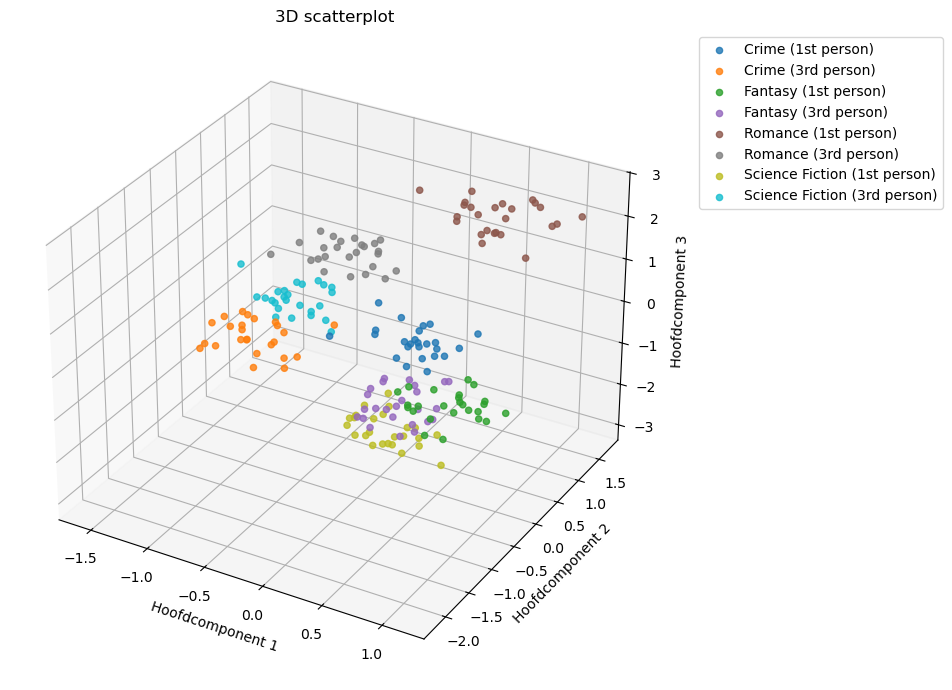

In [22]:
X_pca_3d = compute_pca(X, n_components=3)

figuur = plt.figure(figsize=(10, 7))
as_3d = figuur.add_subplot(111, projection='3d')

for kleur, label in zip(kleuren_lijst, unieke_labels):
    masker = labels_lijst == label
    as_3d.scatter(
        X_pca_3d[masker, 0],
        X_pca_3d[masker, 1],
        X_pca_3d[masker, 2],
        label=label,
        color=kleur,
        alpha=0.8,
    )

as_3d.set_title('3D scatterplot')
as_3d.set_xlabel('Hoofdcomponent 1')
as_3d.set_ylabel('Hoofdcomponent 2')
as_3d.set_zlabel('Hoofdcomponent 3')
as_3d.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Opdracht 3. Analyse

Analyseer de resultaten:
1. Welke categorieën zijn op basis van de PCA-reductie te onderscheiden, en welke niet? 
2. Geef aan hoeveel procent van de informatie bewaard is gebleven in 2D en 3D respectievelijk.
3. Hoeveel dimensies zijn nodig om 90% van de informatie te bewaren?
4. En voor 95%?

vraag 1: met pca zijn duidelijk de categorieen romance (1st person), romance (3rd person), Science Fiction(1st person), Science Fiction (3rd person), Crime (3rd person) en crime (1st person) maar die is echt op nippertje. Welke echt niet onderscheid baar zijn is fantasy (1st person) en fantasy (3rd person).

vraag 2: 69% blijft bewaard als ik naar 2d reducteer en 78% als ik naar 3d reduceer 

vraag 3: 6 dimenties zijn nodig om 90% van de informatie te bewaren 

vraag 4: en 9 dimenties om 95% van de informatie te bewaren

## Deel II: t-Distributed Stochastic Neighbour Embedding (t-SNE)

Een alternatieve methode voor dimensiereductie is _t-Distributed Stochastic Neighbour Embedding_ (t-SNE). 

### Opdracht 4. Toepassing
Gebruik SciKit-Learn om met behulp van t-SNE de data tot 2 dimensies te reduceren en plot het resultaat (wederom met kleuren voor de categorien). 

In [23]:
from sklearn.manifold import TSNE

X_tsne_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X)

plt.figure(figsize=(10, 6))
for kleur, label in zip(kleuren_lijst, unieke_labels):
    masker = labels_lijst == label
    plt.scatter(
        X_tsne_2d[masker, 0],
        X_tsne_2d[masker, 1],
        label=label,
        color=kleur,
        alpha=0.8,
    )

plt.title('2D scatterplot met t-SNE')
plt.xlabel('t-SNE dimensie 1')
plt.ylabel('t-SNE dimensie 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Opdracht 5. Vergelijking

Vergelijk deze met de resultaten van je PCA-implementatie:

1. Hoe verhoudt de zichtbaarheid van de categorieën zich tussen beide resultaten?
2. Hoe verhouden de algoritmes zich in het behoud van informatie?

Beantwoord de volgende vragen los van de data van deze opdracht:

3. Waarvoor zou je PCA en t-SNE inzetten als je te maken krijgt met een onbekende (mogelijk ongelabelde) dataset?
4. Geef een voorbeeld waar PCA de voorkeur heeft boven t-SNE.
5. Geef een voorbeeld waar t-SNE de voorkeur heeft boven PCA.

_Schrijf hier je antwoord._

### Opdracht 6. Project

Als het goed is, heb je op dit moment een eerste idee van de data waar je in het project mee gaat werken. Geef antwoord op onderstaande vragen.

1. Wat is de dimensionaliteit waar je mee te maken hebt?
2. Beschrijf hoe dimensionaliteitsreductie-algoritmen je kunnen helpen de data te verkennen.

_Schrijf hier je antwoord._

bronnen lijst 

- https://numpy.org/devdocs/reference/generated/numpy.linalg.eigh.html 06-03-2026

- https://www.askpython.com/python/string/decimal-formatting-0f-vs-1f 06-03-2026